In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Data loading and exploratory data analysis

## 1.1 Function Analysis

In [24]:
df_function = pd.read_excel("../data/01_FunctionAnalysis_data.xlsx")

### Dataset overview

In [25]:
df_function.head()

,ID,Gender,BMI_Value,AgeGroup,Clinical Treatment,tSTRIDE,tSTANCE,tSWING,tDBLSTANCE,velMEAN
0,72,Male,Low,68-75,Conservative,1.026,0.607,0.419,0.099,1.350
1,73,Female,High,68-75,Conservative,1.184,0.756,0.428,0.149,0.818
2,74,Female,High,60-67,Conservative,1.187,0.729,0.457,0.146,0.891
3,79,Female,Low,68-75,Conservative,1.227,0.773,0.455,0.162,0.717
4,81,Female,High,60-67,Conservative,1.180,0.770,0.410,0.160,0.990


In [26]:
df_function.tail()

,ID,Gender,BMI_Value,AgeGroup,Clinical Treatment,tSTRIDE,tSTANCE,tSWING,tDBLSTANCE,velMEAN
76,2095,Male,Low,68-75,TKR-planned,1.11,0.71,0.40,0.15,0.922
77,2096,Female,Low,60-67,TKR-planned,1.18,0.71,0.47,0.14,1.119
78,2097,Female,Low,68-75,TKR-planned,1.36,0.86,0.49,0.19,0.582
79,2098,Female,Low,60-67,TKR-planned,1.13,0.69,0.44,0.12,1.133
80,2099,Male,Low,60-67,TKR-planned,1.21,0.74,0.47,0.13,1.112


In [27]:
df_function.shape

(81, 10)

In [28]:
df_function.columns

Index(['ID', 'Gender', 'BMI_Value', 'AgeGroup', 'Clinical Treatment',
       'tSTRIDE', 'tSTANCE', 'tSWING', 'tDBLSTANCE', 'velMEAN'],
      dtype='str')

In [29]:
df_function.info()

<class 'pandas.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  81 non-null     int64  
 1   Gender              81 non-null     str    
 2   BMI_Value           81 non-null     str    
 3   AgeGroup            81 non-null     str    
 4   Clinical Treatment  81 non-null     str    
 5   tSTRIDE             81 non-null     float64
 6   tSTANCE             81 non-null     float64
 7   tSWING              81 non-null     float64
 8   tDBLSTANCE          81 non-null     float64
 9   velMEAN             81 non-null     float64
dtypes: float64(5), int64(1), str(4)
memory usage: 6.5 KB


### Missing values and duplicates

In [37]:
df_function.isna().sum()

ID                    0
Gender                0
BMI_Value             0
AgeGroup              0
Clinical Treatment    0
tSTRIDE               0
tSTANCE               0
tSWING                0
tDBLSTANCE            0
velMEAN               0
dtype: int64

In [40]:
df_function.duplicated().sum()

np.int64(0)

### Variable definition

In [58]:
categorical_cols = ["Gender", "BMI_Value", "AgeGroup", "Clinical Treatment"]

numerical_cols = ["tSTRIDE", "tSTANCE", "tSWING", "tDBLSTANCE", "velMEAN"]

### Descriptive statistics and distributions

In [59]:
df_function[numerical_cols].describe()

,tSTRIDE,tSTANCE,tSWING,tDBLSTANCE,velMEAN
count,81.000000,81.000000,81.000000,81.000000,81.000000
mean,1.178963,0.737556,0.440889,0.156185,0.929173
std,0.115589,0.089332,0.036216,0.043524,0.203342
min,0.940000,0.570000,0.360000,0.090000,0.490000
25%,1.110000,0.680000,0.420000,0.130000,0.800000
50%,1.160000,0.710000,0.440000,0.150000,0.938000
75%,1.240000,0.780000,0.470000,0.170000,1.044000
max,1.450000,1.000000,0.520000,0.340000,1.365000


In [60]:
for col in categorical_cols:
    print(df_function[col].value_counts())
    print("-" * 30)

Gender
Female    49
Male      32
Name: count, dtype: int64
------------------------------
BMI_Value
High          46
Low           35
Name: count, dtype: int64
------------------------------
AgeGroup
68-75    45
60-67    36
Name: count, dtype: int64
------------------------------
Clinical Treatment
Conservative    46
TKR-planned     35
Name: count, dtype: int64
------------------------------


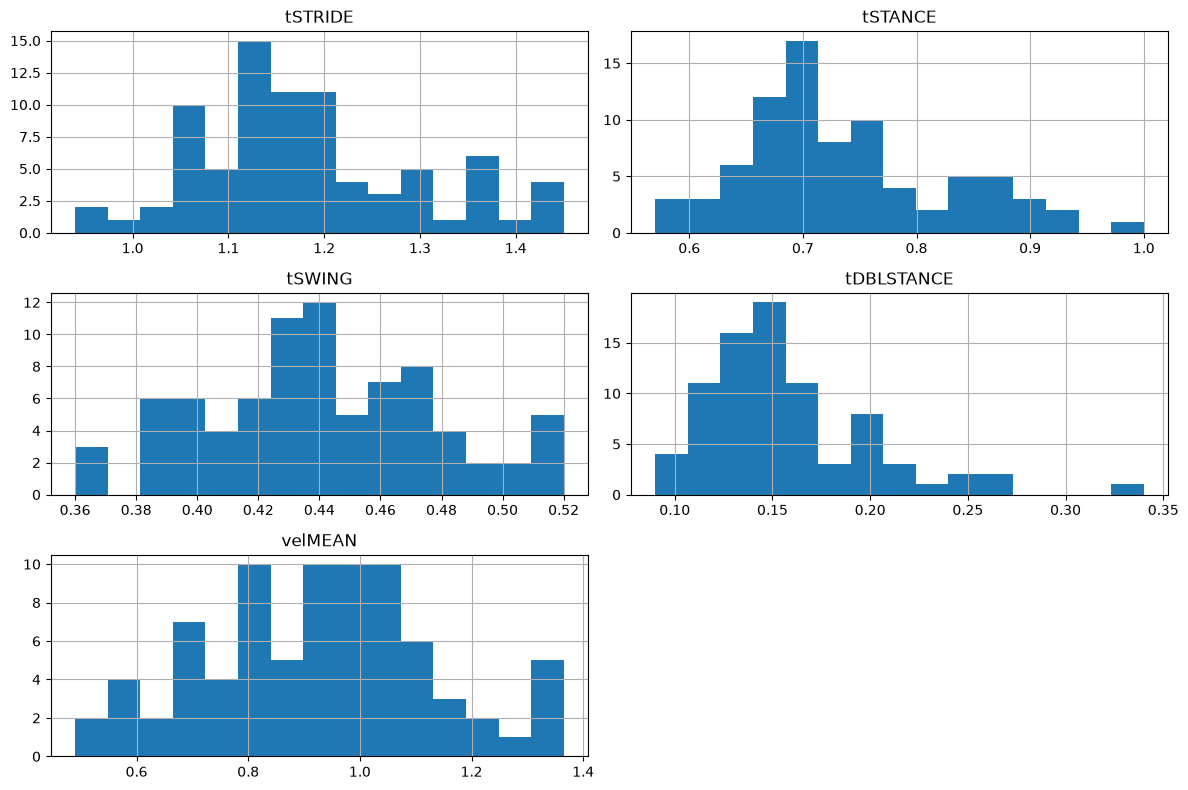

In [ ]:
df_function[numerical_cols].hist(figsize=(12, 8), bins=15)
plt.tight_layout()
plt.show()

### Outlier inspection

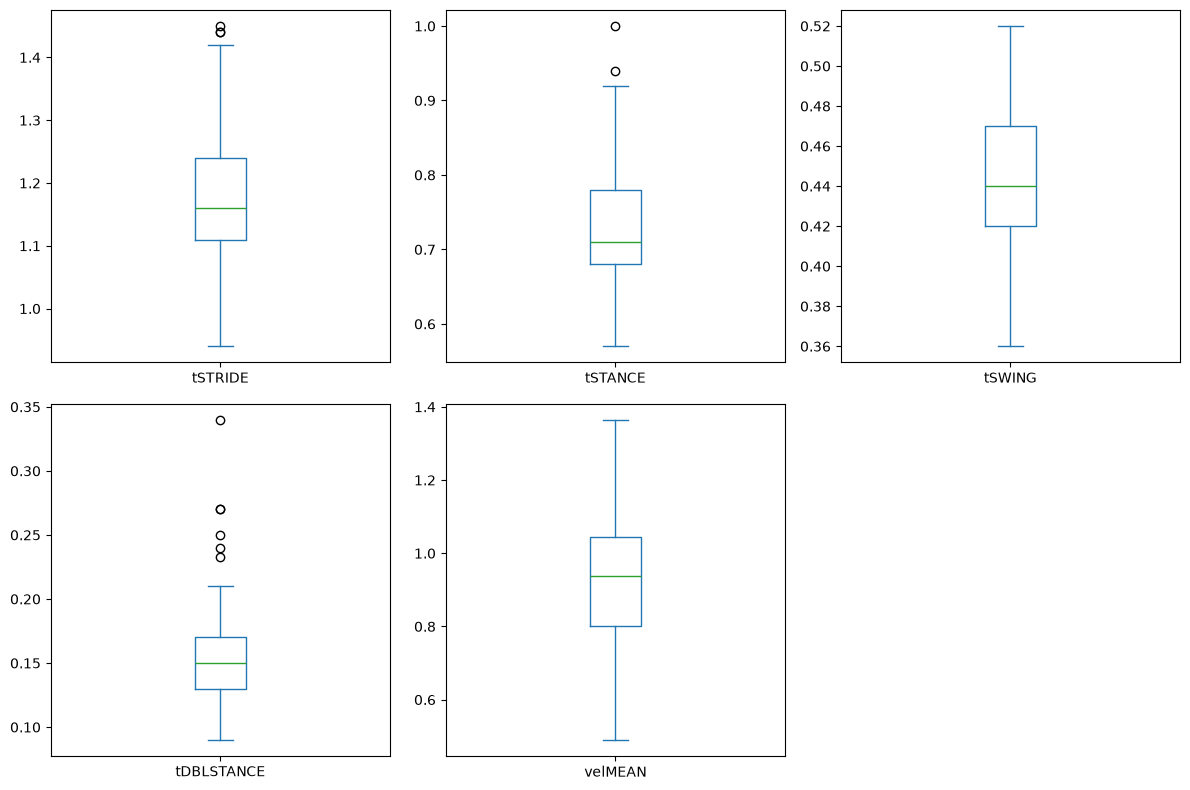

In [52]:
df_function[numerical_cols].plot(
    kind="box",
    subplots=True,
    layout=(2, 3),
    figsize=(12, 8)
)

plt.tight_layout()
plt.show()

### Correlations

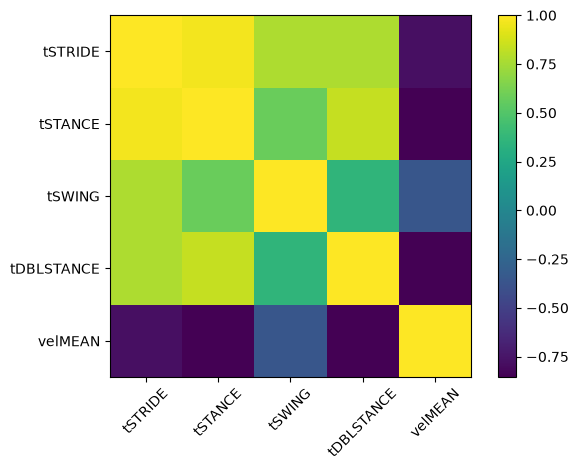

In [53]:
corr = df_function[numerical_cols].corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()

In [61]:
df_function.groupby("Clinical Treatment")[numerical_cols].mean()

,tSTRIDE,tSTANCE,tSWING,tDBLSTANCE,velMEAN
Clinical Treatment,,,,,
Conservative,1.140370,0.704870,0.434565,0.139522,1.006826
TKR-planned,1.229686,0.780514,0.449200,0.178086,0.827114


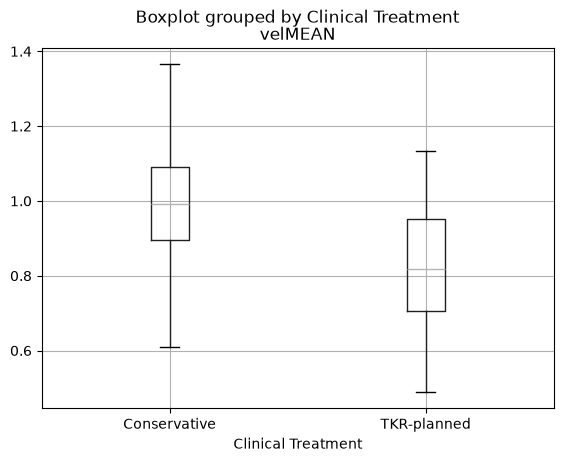

In [62]:
df_function.boxplot(
    column="velMEAN",
    by="Clinical Treatment"
)

plt.show()

### Main observations